In [1]:
!pip install brisque

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.2/40.2 kB 2.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.3/140.3 kB 5.7 MB/s eta 0:00:00
  Created wheel for libsvm-official: filename=libsvm_official-3.36.0-cp312-cp312-linux_x86_64.whl size=124635 sha256=0d5d6e75c527bdb7ae96c36bec3542ea0438f15d739e0888632e101eabd6e69d
  Stored in directory: /root/.cache/pip/wheels/df/65/4b/c3cdece6e5fa7eebef116be2d5a309f7ac50c90183cbe12c92
Successfully built libsvm-official


In [2]:
from google.colab import drive
drive.mount('/content/drive')
%env INPUT_PATH=/content/drive/MyDrive/sihdr/input/clip_97
%env REFERENCE_PATH=/content/drive/MyDrive/sihdr/reference


Mounted at /content/drive
env: INPUT_PATH=/content/drive/MyDrive/sihdr/input/clip_97
env: REFERENCE_PATH=/content/drive/MyDrive/sihdr/reference


In [3]:
import os

import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from brisque import BRISQUE
from skimage.metrics import structural_similarity as ssim
from torch.utils.data import DataLoader
from torchvision import models

os.environ["OPENCV_IO_ENABLE_OPENEXR"] = "1"
import os
import random
import time
from math import nan

import matplotlib.pyplot as plt
import numpy as np
import torch
from skimage.metrics import structural_similarity as ssim
from torch.utils.data import DataLoader, Dataset


In [4]:

class ToneMappingVGG(nn.Module):
    def __init__(self, target_layers: list[str] = ["0" , "1" , "2"]):
        super().__init__()
        self.target_layers = target_layers

        vgg_model = models.vgg16(weights=models.VGG16_Weights.DEFAULT).features
        self.model = vgg_model.eval()
        self._freeze_parameters()

        self.model_out: dict[str, torch.Tensor] = {}
        self._register_hooks()

    def _freeze_parameters(self):
        for parameter in self.model.parameters():
            parameter.requires_grad = False

    def _register_hooks(self):
        layer_dict = dict(self.model._modules)
        for layer_name in self.target_layers:
            layer = layer_dict[layer_name]
            layer.register_forward_hook(self._create_hook(layer_name))

    def _create_hook(self, layer_name):
        def hook(module: nn.Module, input: torch.Tensor, output: torch.Tensor) -> None:
            self.model_out[layer_name] = output
        return hook

    def forward(self, image):
        _ = self.model(image)
        return {name: self.model_out[name] for name in self.target_layers}

class ToneMappingFeatureConstrastMaskingLoss(nn.Module):
    def __init__(self, patch_size: int = 13, eps: float = 1e-4, alpha_hdr: float = 0.5, alpha_tm: float = 1.0):
        super().__init__()
        self.eps = eps
        self.alpha_hdr = alpha_hdr
        self.alpha_tm = alpha_tm
        self.avg_pool = nn.AvgPool2d(
            kernel_size=patch_size,
            stride=1,
            padding=patch_size // 2,
            count_include_pad=False
        )

        self.vgg_extractor = ToneMappingVGG()
        self.loss_function = nn.L1Loss()
        self.patch_size = patch_size

    def calc_gaussian_filter(self, f_p):
        channels = f_p.shape[1]
        kernel = cv2.getGaussianKernel(self.patch_size, 3)
        kernel = torch.tensor(kernel @ kernel.T, dtype=f_p.dtype, device=f_p.device)
        kernel = kernel.unsqueeze(0).unsqueeze(0)  # (1, 1, H, W)
        kernel = kernel.repeat(channels, 1, 1, 1)  # apply to each channel

        padding = self.patch_size // 2
        return F.conv2d(f_p, kernel, padding=padding, groups=channels)

    def _calculate_feature_contrast(self, f_p):
        mu_b = self.calc_gaussian_filter(f_p)
        C_p = (f_p - mu_b) / (torch.abs(mu_b) + self.eps)
        #C_p = C_p.clamp(min=-1000.0, max=1000.0)
        var_b = self.calc_gaussian_filter(torch.pow(f_p - mu_b, 2))
        sigma_b = torch.sqrt(var_b.clamp(min=0) + self.eps)

        return C_p, mu_b, sigma_b

    def _calculate_fcm_masking(self, C_p, mu_b, sigma_b, alpha):
        sign_C = C_p / (torch.abs(C_p) + self.eps)
        M_s = sign_C * torch.pow(torch.abs(C_p), alpha)
        #M_s = M_s.clamp(min=-1000.0, max=1000.0)
        M_n = sigma_b / (torch.abs(mu_b) + self.eps)
        f_VGG_I = M_s / (1 + M_n)

        return f_VGG_I

    def forward(self, original, generated):

        features_hdr = self.vgg_extractor(original)
        features_tm = self.vgg_extractor(generated)

        loss = 0.0
        for layer_name in features_hdr.keys():
            f_hdr = features_hdr[layer_name].to(original.device)
            f_tm = features_tm[layer_name].to(generated.device)

            C_hdr, mu_b_hdr, sigma_b_hdr = self._calculate_feature_contrast(f_hdr)
            f_VGG_hdr = self._calculate_fcm_masking(C_hdr, mu_b_hdr, sigma_b_hdr, self.alpha_hdr)

            C_tm, mu_b_tm, sigma_b_tm = self._calculate_feature_contrast(f_tm)
            f_VGG_tm = self._calculate_fcm_masking(C_tm, mu_b_tm, sigma_b_tm, self.alpha_tm)

            layer_loss = F.l1_loss(f_VGG_tm, f_VGG_hdr)
            loss += layer_loss

        return loss


def ulaw(image):
    image = image.cpu().detach().numpy()
    median_value = np.median(image)
    scale = 8.759 * np.power(median_value, 2.148) + 0.1494 * np.power(
        median_value, -2.067
    )
    transformed = np.log(1 + scale * image) / np.log(1 + scale)
    transformed = torch.from_numpy(transformed).to("cuda")
    return transformed

In [5]:
def evaluate_brisque(image):

    metric = BRISQUE(url=False)

    img_conv = image.cpu().detach().numpy()
    img_conv = np.transpose(img_conv, (1, 2, 0))

    img_process = (img_conv * 255).astype(np.uint8)
    return metric.score(img=img_process)


def evaluate_SSIM(original, generated) :
    score, dif = ssim(original, generated, full=True)
    return score

In [6]:
class ToneMappingEncoder(nn.Module):
    def __init__(self):
        super(ToneMappingEncoder, self).__init__()
        self.first_cov = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, stride=1, padding="same"), nn.ReLU()
        )
        self.second_cov = nn.Sequential(
            nn.Conv2d(16, 32, kernel_size=3, stride=1, padding="same"), nn.ReLU()
        )
        self.third_cov = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding="same"), nn.ReLU()
        )

    def forward(self, x):
        y = self.first_cov(x)
        y = self.second_cov(y)
        y = self.third_cov(y)
        return y

class ToneMappingDecoder(nn.Module):
    def __init__(self):
        super(ToneMappingDecoder, self).__init__()
        self.first_deconv = nn.Sequential(
            nn.Conv2d(192, 32, kernel_size=3, stride=1, padding="same"),
            nn.ReLU(),
        )
        self.second_deconv = nn.Sequential(
            nn.Conv2d(32, 16, kernel_size=3, stride=1, padding="same"),
            nn.ReLU(),
        )
        self.final_cov = nn.Sequential(
            nn.Conv2d(16, 3, kernel_size=3, stride=1, padding="same"),
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x, e_low, e_mid, e_high):
        y = self.first_deconv(x)
        y = self.second_deconv(y)
        y = self.final_cov(y)
        return self.sigmoid(y + e_low + e_mid + e_high)


class ToneMappingNetwork(nn.Module):
    def __init__(self):
        super(ToneMappingNetwork, self).__init__()
        self.encoder = ToneMappingEncoder()
        self.fusion_module_1 = nn.Conv2d(
            in_channels=3*64, out_channels=192, kernel_size=3, stride=1, padding="same"
        )
        self.fusion_module_2 = nn.Conv2d(
            in_channels=192, out_channels=192, kernel_size=1, stride=1, padding="same"
        )
        self.decoder = ToneMappingDecoder()

    def forward(self, e_1, e_2, e_3):
        e_1_encoded = self.encoder(e_1)
        e_2_encoded = self.encoder(e_2)
        e_3_encoded = self.encoder(e_3)
        combined_encoding = torch.cat((e_1_encoded, e_2_encoded, e_3_encoded), dim=1)
        fuse_1 = self.fusion_module_1(combined_encoding)
        fuse_2 = self.fusion_module_2(fuse_1)
        decoded = self.decoder(fuse_2, e_1, e_2, e_3)
        return decoded

In [7]:
def read_exr_file(image_path: str):
        image = cv2.imread(
            image_path,
            flags=cv2.IMREAD_ANYCOLOR | cv2.IMREAD_ANYDEPTH
        )
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        return image

def normalize_hdr_image(hdr_image):
    mean_intensity = hdr_image.mean()
    normalized_image = (0.5 * hdr_image) / mean_intensity
    return normalized_image


def generate_exposures(hdr_image):
    x_p = 1.21497
    log2 = torch.log(torch.tensor(2.0))

    c_start = torch.log(x_p / hdr_image.max()) / log2
    c_end = torch.log(x_p / torch.quantile(hdr_image, 0.5)) / log2

    c_mid = (c_start + c_end) / 2

    e_low = np.clip((2 ** c_start) * hdr_image, 0, 1)
    e_mid = np.clip((2 ** c_mid) * hdr_image, 0, 1)
    e_high = np.clip((2 ** c_end) * hdr_image, 0, 1)

    return e_low, e_mid, e_high

In [8]:
class ToneMappingDataset(Dataset):
    def __init__(self, dir_path: str):
        self.dir_path = dir_path
        self.files = [f for f in os.listdir(dir_path) if f.endswith(".exr")]

    def __len__(self) -> int:
        return len(self.files)
    def _resize_image(self, image):
        if isinstance(image, torch.Tensor):
          image = image.cpu().numpy()
        return cv2.resize(image, (256, 256), interpolation=cv2.INTER_AREA)

    def __getitem__(self, idx: int):
        base_filename = self.files[idx]
        file_path = os.path.join(self.dir_path, base_filename)

        hdr_image = read_exr_file(file_path)
        hdr_image = normalize_hdr_image(hdr_image)

        hdr_image_for_math = torch.tensor(hdr_image , dtype=torch.float32)
        e_low, e_mid, e_high = generate_exposures(hdr_image_for_math)
        e_low = self._resize_image(e_low)
        e_mid = self._resize_image(e_mid)
        e_high = self._resize_image(e_high)
        hdr_image = self._resize_image(hdr_image)

        low_exposure = torch.tensor(e_low, dtype=torch.float32).permute(2, 0, 1)
        mid_exposure = torch.tensor(e_mid, dtype=torch.float32).permute(2, 0, 1)
        high_exposure = torch.tensor(e_high, dtype=torch.float32).permute(2, 0, 1)
        hdr_image = torch.tensor(hdr_image, dtype=torch.float32).permute(2, 0, 1)

        return low_exposure, mid_exposure, high_exposure, hdr_image


In [9]:
def validate(model, loader, criterion, device, epoch=None):
    model.eval()
    total_loss = 0
    batch_count = 0
    start_time = time.time()

    with torch.no_grad():
        for x_low, x_mid, x_high, x_hdr in loader:
            x_low, x_mid, x_high, x_hdr = x_low.to(device), x_mid.to(device), x_high.to(device), x_hdr.to(device)
            x_ldr = model(x_low, x_mid, x_high)
            loss = criterion(x_hdr, x_ldr)

            total_loss += loss.item()
            batch_count += 1

    avg_loss = total_loss / len(loader)
    val_time = time.time() - start_time
    print(f"Epoch {epoch} Validation - Loss: {avg_loss:.6f}, "
                   f"Time: {val_time:.2f}s")

    return avg_loss

def train(
    model,
    train_dataloader,
    val_dataloader,
    criterion,
    optimizer,
    device,
    epochs,
    scheduler
):
    print("START")
    patience = 5
    best_val_loss = float("inf")
    epochs_without_improvement = 0
    for epoch in range(epochs):
        epoch_loss = 0

        for x_low, x_mid, x_high, x_hdr in train_dataloader:
            x_low, x_mid, x_high, x_hdr = x_low.to(device), x_mid.to(device), x_high.to(device), x_hdr.to(device)

            optimizer.zero_grad()
            x_ldr = model(x_low, x_mid, x_high)
            train_loss = criterion(x_hdr, x_ldr)

            train_loss.backward()
            optimizer.step()

            epoch_loss += train_loss.item()
        val_loss = validate(model, val_dataloader, criterion, device, epoch)

        epoch_loss = epoch_loss/len(train_dataloader)
        print(f"Epoch {epoch + 1} Summary:")
        print(f"  Train Loss: {train_loss:.6f}")
        print(f"  Val Loss: {val_loss:.6f}")

        if val_loss < best_val_loss:
            improvement = best_val_loss - val_loss
            best_val_loss = val_loss
            epochs_without_improvement = 0
            model_filename = f"best_model"
            model_filename += ".pth"
            torch.save(model.state_dict(), model_filename)
            print(f"  *** NEW BEST MODEL! Improvement: {improvement:.6f}")
            print(f"  Saved as: {model_filename}")
        else:
            epochs_without_improvement += 1
            print(f"  No improvement (best: {best_val_loss:.6f})")
            print(f"  Epochs without improvement: {epochs_without_improvement}/{patience}")

        # Early stopping check
        if epochs_without_improvement >= patience:
            print("="*80)
            print(f"EARLY STOPPING triggered after {epoch + 1} epochs")
            print(f"No improvement for {patience} consecutive epochs")
            print(f"Best validation loss: {best_val_loss:.6f}")
            print("="*80)
            break

        print("-" * 40)
        scheduler.step()

    print("="*80)
    print("TRAINING COMPLETED")
    print(f"Best validation loss: {best_val_loss:.6f}")
    print(f"Final model saved as: {model_filename}")

    return model

In [10]:
def set_seed(seed = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [ ]:
def split_dataset(image_paths, split_root):
    set_seed()
    random.shuffle(image_paths)
    n = len(image_paths)
    n_train = int(n * 0.7)
    n_valid = int(n * 0.1)
    n_test = int(n * 0.2)

    splits = {
        'train': image_paths[:n_train],
        'valid': image_paths[n_train:n_train + n_valid],
        'test': image_paths[n_train+n_valid:n_train+n_valid+n_test]
    }

    for split, paths in splits.items():
        split_dir = os.path.join(split_root, split)
        os.makedirs(split_dir, exist_ok=True)
        for path in paths:
            filename = os.path.basename(path)
            os.rename(path, os.path.join(split_dir, filename))
#image_paths = [os.path.join(os.getenv('REFERENCE_PATH'), f)
                      #for f in os.listdir(os.getenv('REFERENCE_PATH')) if f.endswith('.exr')]
#split_dataset(image_paths, "/content/drive/MyDrive/sihdr/")

In [11]:

torch.cuda.empty_cache()
set_seed()
device_type = "cuda" if torch.cuda.is_available() else "cpu"

device = torch.device(device_type)
model = ToneMappingNetwork().to(device)
criterion = ToneMappingFeatureConstrastMaskingLoss()
criterion.eval()
criterion.to(device)
lr = 0.001
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
lr_scheduler = torch.optim.lr_scheduler.StepLR(
            optimizer, step_size=10, gamma=0.9
        )
epochs = 100
dataset_train = ToneMappingDataset("/content/drive/MyDrive/sihdr/train/")
dataset_valid = ToneMappingDataset("/content/drive/MyDrive/sihdr/valid/")
dataset_test = ToneMappingDataset("/content/drive/MyDrive/sihdr/test/")

print(f"Loaded {len(dataset_train)} HDR train images")
print(f"Loaded {len(dataset_valid)} HDR valid images")
print(f"Loaded {len(dataset_test)} HDR test images")
dataloader_train = DataLoader(dataset_train, batch_size=1, shuffle=True)
dataloader_valid = DataLoader(dataset_valid, batch_size=1, shuffle=False)
dataloader_test = DataLoader(dataset_test, batch_size=1, shuffle=False)

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:04<00:00, 132MB/s]


Loaded 127 HDR train images
Loaded 18 HDR valid images
Loaded 36 HDR test images


In [ ]:
load_model = True

if not load_model:
  try:
    torch.cuda.empty_cache()
    train(model, dataloader_train, dataloader_valid, criterion, optimizer, device, epochs, lr_scheduler)
  finally:
    SAVE_DIR = "/content/drive/MyDrive/sihdr/models"
    MODEL_FILENAME = 'best_tm_model_2.pth'
    SAVE_PATH = os.path.join(SAVE_DIR, MODEL_FILENAME)
    torch.save(model.state_dict(), SAVE_PATH)
else:
    LOAD_PATH = '/content/drive/MyDrive/sihdr/models/best_tm_model_2.pth'
    state_dict = torch.load(LOAD_PATH, map_location=device)
    model.load_state_dict(state_dict)

In [12]:
def brisque(image):

    metric = BRISQUE(url=False)

    img_conv = image.cpu().detach().numpy()
    img_conv = np.transpose(img_conv, (1, 2, 0))

    img_process = (img_conv * 255).astype(np.uint8)
    return metric.score(img=img_process)

def evaluate_brisque(model, data, device, option):
    model.eval()
    total_score = 0.0
    num_images = 0

    for x_low, x_mid, x_high, x_hdr in data:
        x_low, x_mid, x_high, x_hdr = x_low.to(device), x_mid.to(device), x_high.to(device), x_hdr.to(device)

        optimizer.zero_grad()
        if option == 0:
          x_ldr = model(x_low, x_mid, x_high)
        else:
          x_ldr = model(x_hdr)

        for i in range(x_ldr.size(0)):
            score = brisque(x_ldr[i])
            total_score += score
            num_images += 1

    average_score = total_score / max(num_images, 1)
    print(f"Average Brisque: {average_score:.4f}")
    return average_score

def SSIM(original, generated) -> float:
    original_np = original.detach().cpu().clamp(0, 1).permute(1, 2, 0).numpy()
    generated_np = generated.detach().cpu().clamp(0, 1).permute(1, 2, 0).numpy()

    score = ssim(original_np, generated_np, data_range=1.0, channel_axis=2)
    return float(score)

def evaluate_SSIM(model, data, device, option):
    model.eval()
    total_score = 0.0
    num_images = 0

    for x_low, x_mid, x_high, x_hdr in data:
        x_low, x_mid, x_high, x_hdr = x_low.to(device), x_mid.to(device), x_high.to(device), x_hdr.to(device)
        with torch.no_grad():
          if option == 0:
            x_ldr = model(x_low, x_mid, x_high)
          else:
            x_ldr = model(x_hdr)
          x_ldr = torch.nan_to_num(x_ldr, nan=0.0, posinf=1.0, neginf=0.0)
          for i in range(x_ldr.size(0)):
              score = SSIM(x_ldr[i], x_hdr[i])

              total_score += score
              num_images += 1

    average_score = total_score / max(num_images, 1)
    print(f"Average SSIM: {average_score:.4f}")
    return average_score


In [13]:
class MantiukTMOModule(nn.Module):
    def __init__(self):
        super().__init__()

    def tone_map_mantiuk(self, image):
        image = image.squeeze(0)

        image_np = image.permute(1, 2, 0).cpu().numpy().astype(np.float32)


        tonemap_operator = cv2.createTonemapMantiuk(
            gamma=2.2,
            scale=0.85,
            saturation=1.2
        )

        result_np = tonemap_operator.process(src=image_np)
        result = torch.from_numpy(result_np).float().permute(2, 0, 1)
        result = result.unsqueeze(0)
        return result.to(image.device)

    def forward(self, x) -> torch.Tensor:
      return self.tone_map_mantiuk(x)

class ReinhardTMOModule(nn.Module):
    def __init__(self):
        super().__init__()

    def tone_map_reinhard(self, image):
      image = image.squeeze(0)
      image = image.squeeze(0)
      image_np = image.permute(1, 2, 0).cpu().numpy().astype(np.float32)


      tonemap_operator = cv2.createTonemapReinhard(
      gamma=2.2,
      intensity=0.0,
      light_adapt=0.0,
      color_adapt=0.0
      )
      result = tonemap_operator.process(src=image_np)
      result = torch.from_numpy(result).float().permute(2, 0, 1)
      result = result.unsqueeze(0)
      return result.to(image.device)

    def forward(self, x):

      return self.tone_map_reinhard(x)


Compare Mantiuk Reinhard Tonemap models

---



In [14]:
mantiuk = MantiukTMOModule()
reinhard = ReinhardTMOModule()
model = model

In [15]:
def viusalize_image(generated_images, original_images, model_names):

    for gen_images, org_images, model_name in zip(generated_images, original_images, model_names):
      for gen_image, original_image, mdl_name in zip(gen_images, org_images, model_name):
        original_image = original_image.detach().permute(0, 2, 3, 1).cpu()
        gen_image    = gen_image.detach().permute(0, 2, 3, 1).cpu()

        fig, axes = plt.subplots(1, 2, figsize=(12, 3))
        axes[0].imshow(original_image.clip(0, 1).squeeze())
        axes[0].set_title("Hdr")
        axes[0].axis("off")

        axes[1].imshow(gen_image.clip(0, 1).squeeze())
        axes[1].set_title("Sdr")
        axes[1].axis("off")
        plt.tight_layout()
        print(mdl_name)
        plt.show()




Tonemap


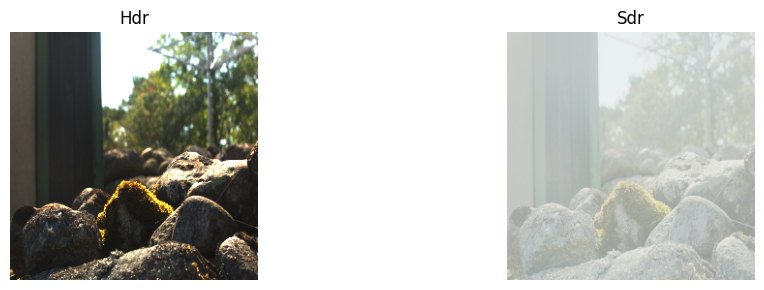

Mantiuk


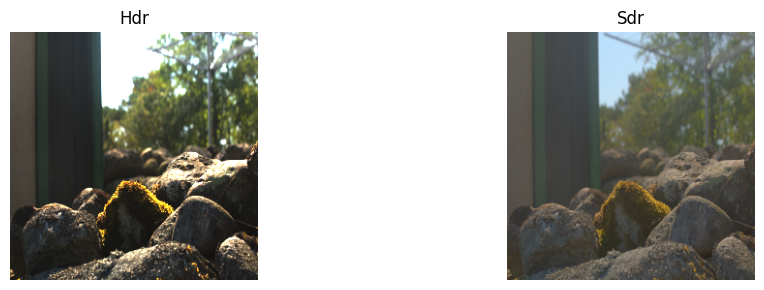

Reinhard


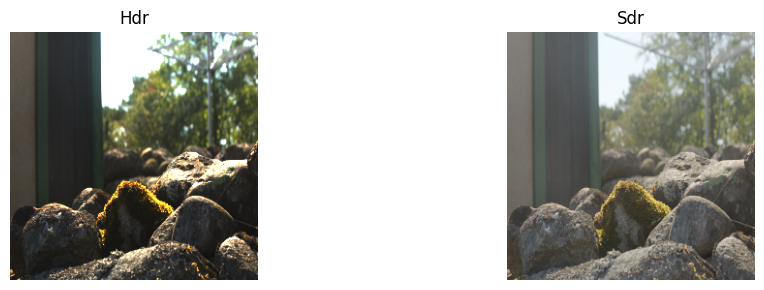

Tonemap


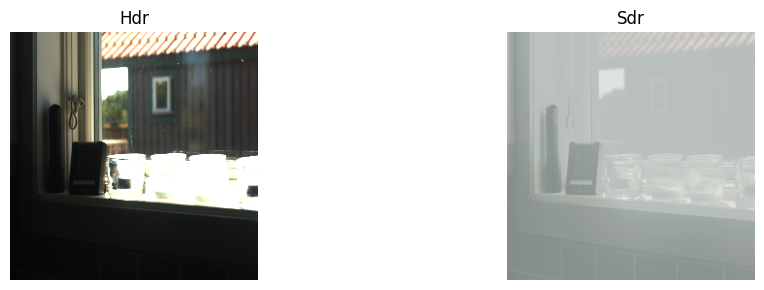

Mantiuk


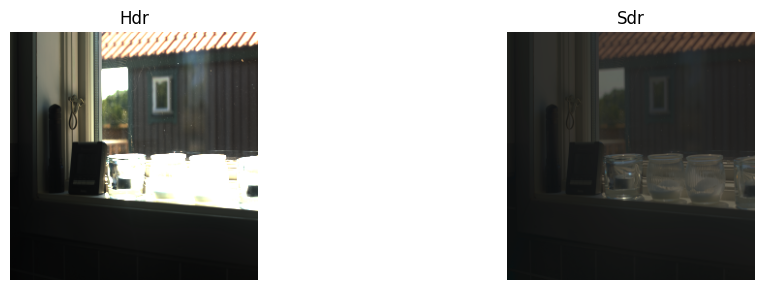

Reinhard


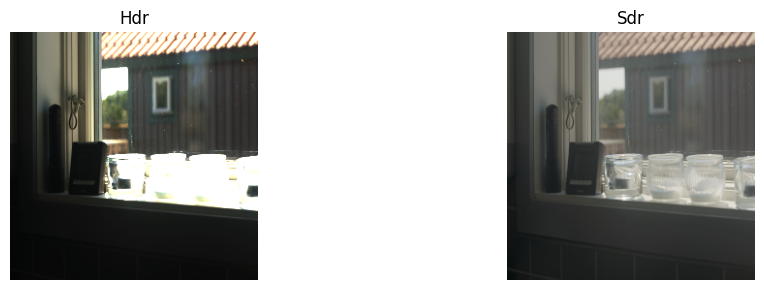

Tonemap


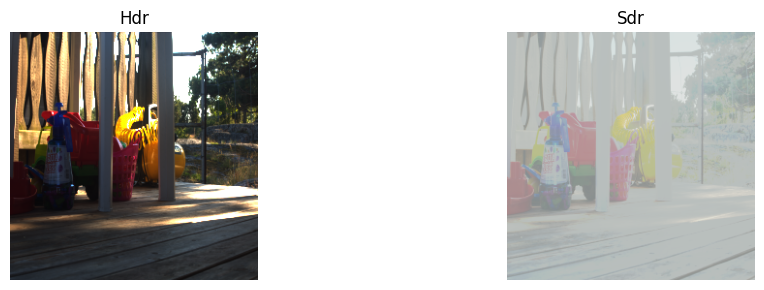

Mantiuk


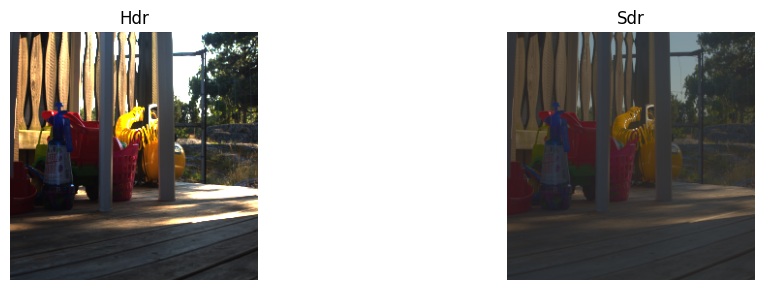

Reinhard


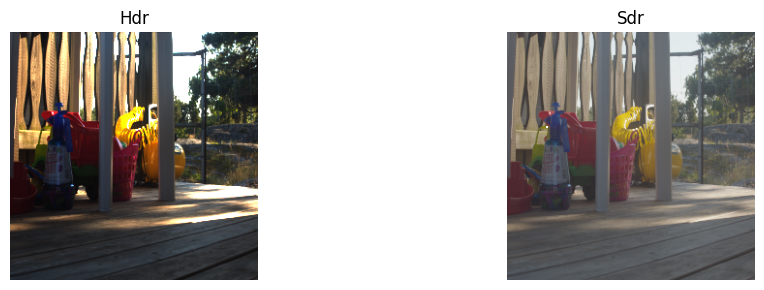

Tonemap


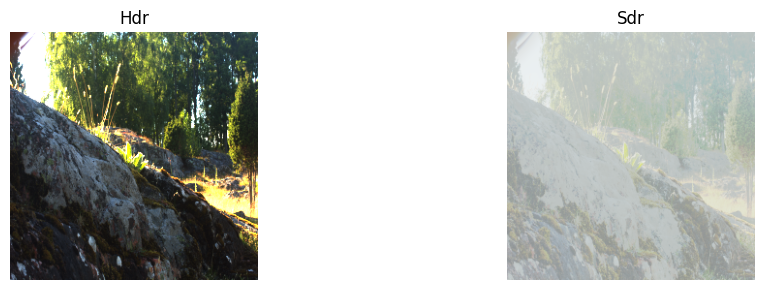

Mantiuk


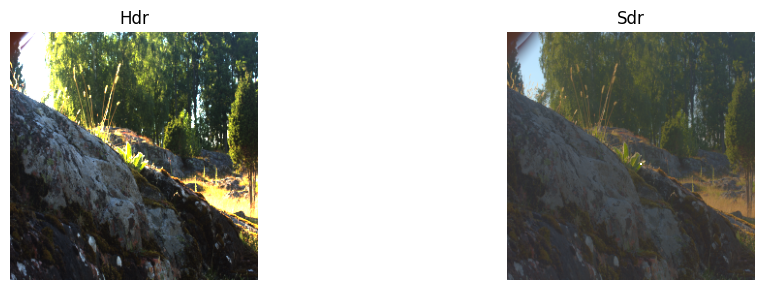

Reinhard


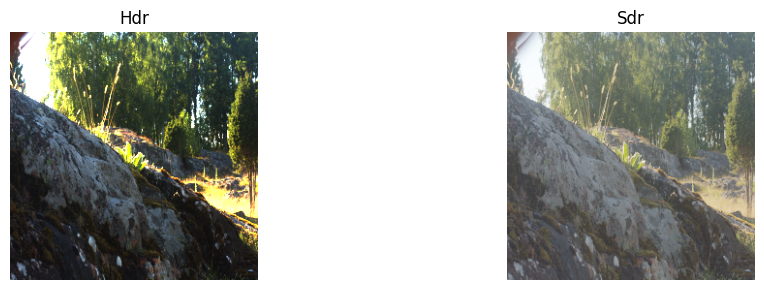

Tonemap


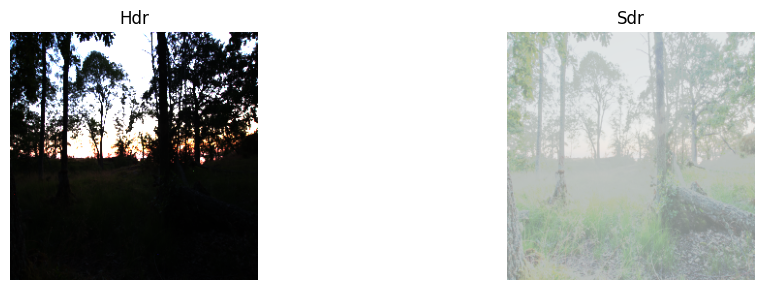

Mantiuk


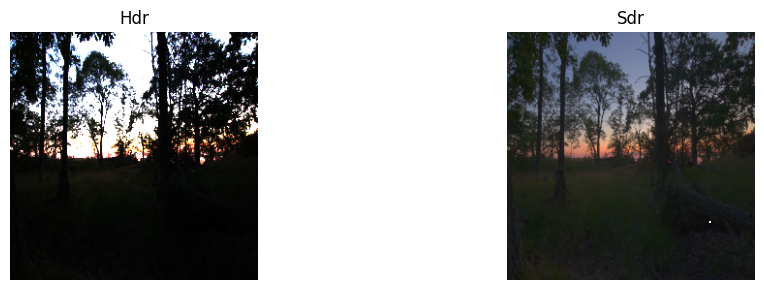

Reinhard


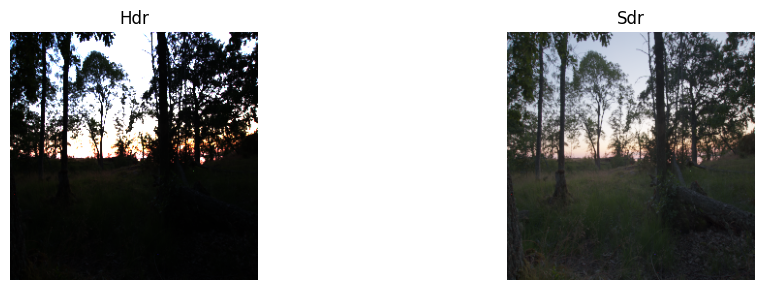

Tonemap


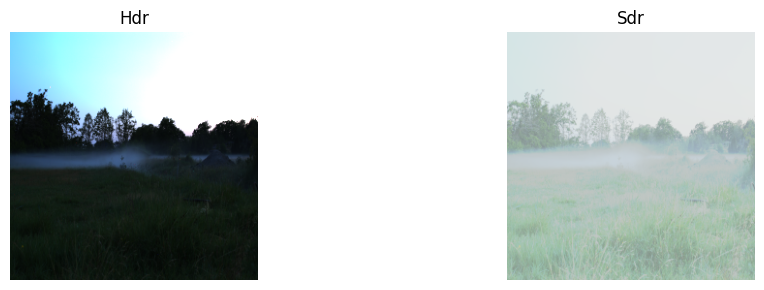

Mantiuk


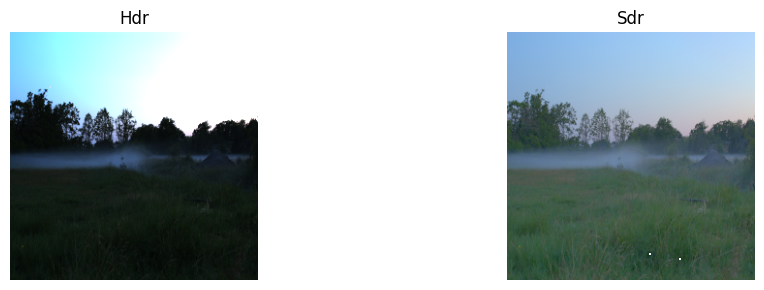

Reinhard


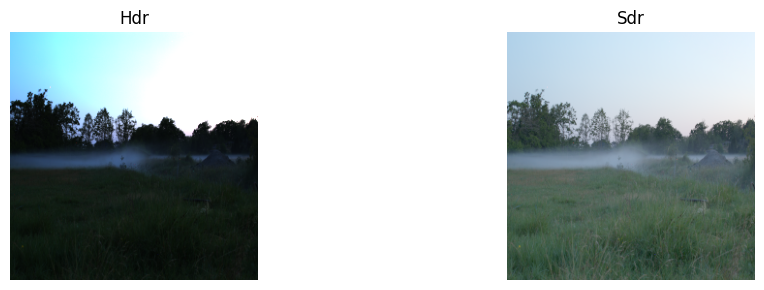

Tonemap


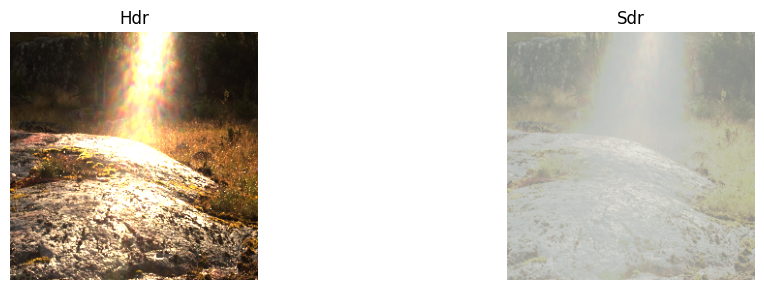

Mantiuk


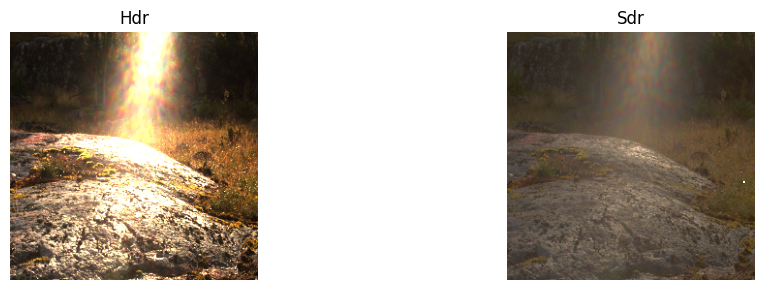

Reinhard


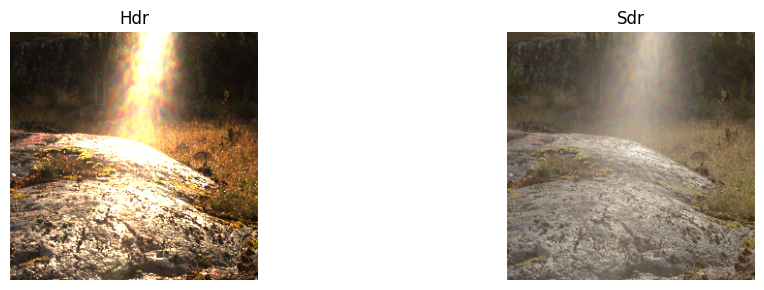

Tonemap


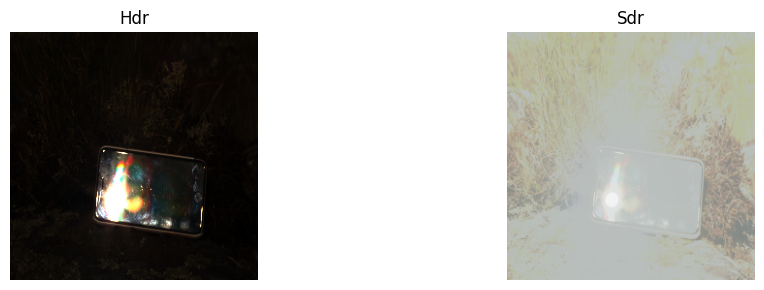

Mantiuk


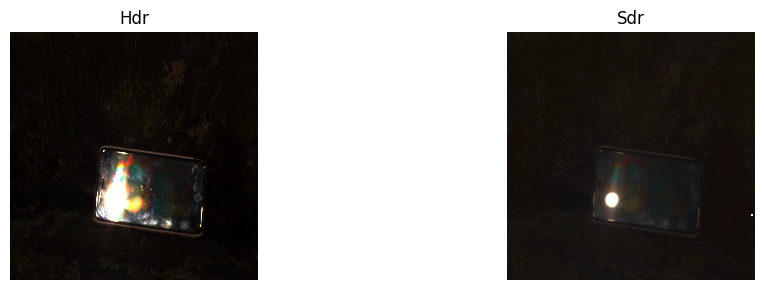

Reinhard


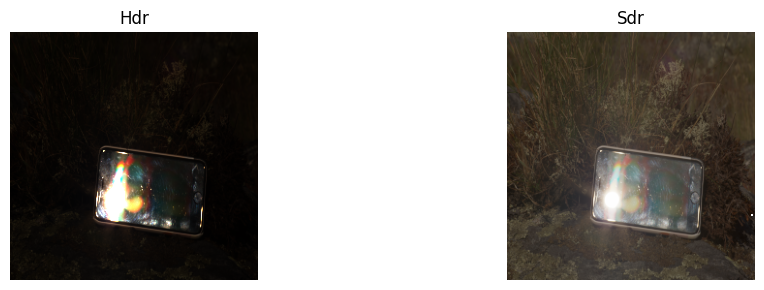

Tonemap


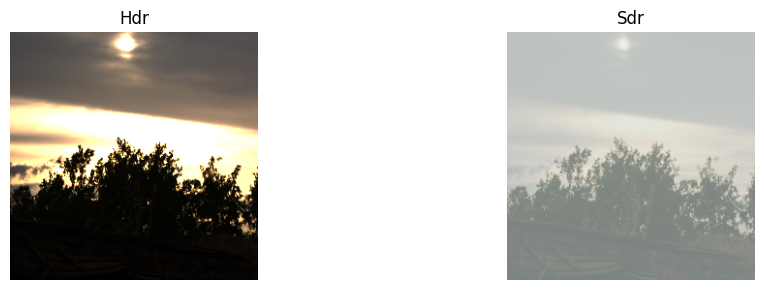

Mantiuk


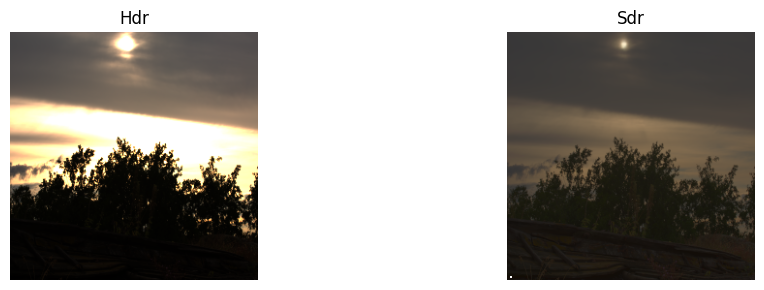

Reinhard


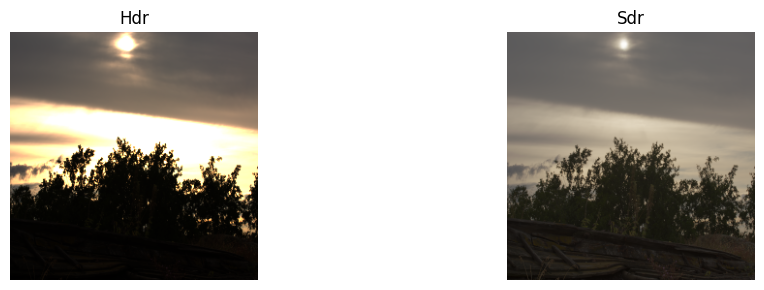

Tonemap


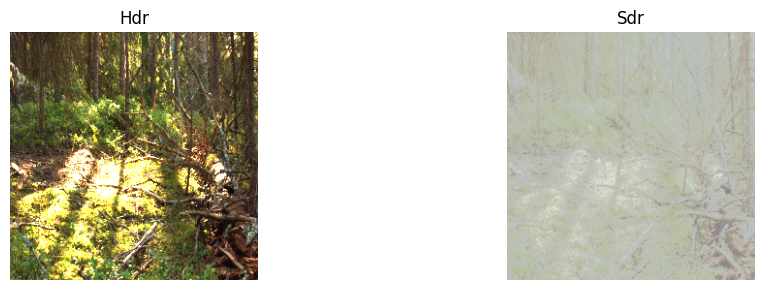

Mantiuk


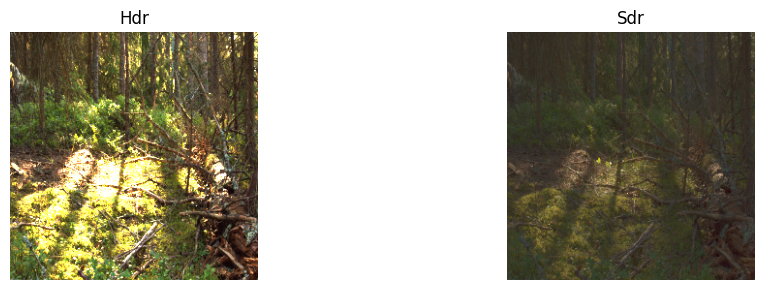

Reinhard


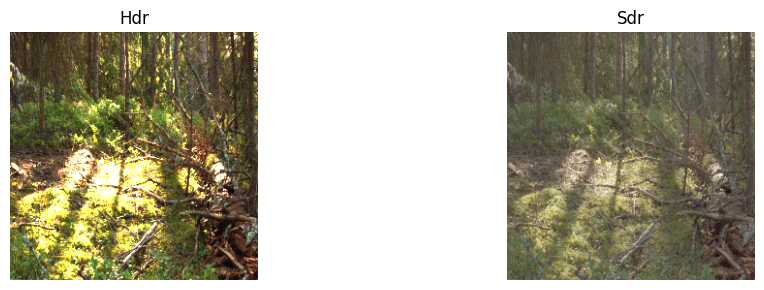

In [ ]:
generated_images = []
original_images = []
model_names = []
i = 0
for x_low, x_mid, x_high, x_hdr in dataloader_test:
  i += 1
  if(i > 10):
    break
  x_low, x_mid, x_high, x_hdr = x_low.to(device), x_mid.to(device), x_high.to(device), x_hdr.to(device)
  x_ldr = model(x_low, x_mid, x_high)


  generated_images.append([x_ldr])
  original_images.append([x_hdr])
  model_names.append(["Tonemap"])

  generated_images.append([mantiuk(x_hdr)])
  original_images.append([x_hdr])
  model_names.append(["Mantiuk"])

  generated_images.append([reinhard(x_hdr)])
  original_images.append([x_hdr])
  model_names.append(["Reinhard"])
viusalize_image(generated_images, original_images, model_names)

In [ ]:

for label, elem in {"Our model":model, "Mantiuk":mantiuk, "Reinhard":reinhard}.items():
    print(label)
    if label == "Our model":
      option = 0
    else:
      option = 1
    evaluate_SSIM(elem, dataloader_test, device, option)
    evaluate_brisque(elem, dataloader_test, device, option)
print("CLIP 97")
dataset_test.files.sort()
clip_files = [f for f in os.listdir("/content/drive/MyDrive/sihdr/clip_97/") if f.endswith(".png")]
clip_files.sort()
clip_97 = list(zip(dataset_test.files, clip_files))
ssim_score = 0
brisque_score = 0
for original, generated in clip_97:
    ssim_score += SSIM(original, generated)
    brisque_score += brisque(generated)
average_score_ssim = ssim_score / len(clip_97)
average_score_brisque = brisque_score / len(clip_97)
print(f"Average SSIM: {average_score_ssim:.4f}")
print(f"Average Brisque: {average_score_brisque:.4f}")


Our model
Average SSIM: 0.2509
Average Brisque: 32.2127
Mantiuk
Average SSIM: 0.5744


/tmp/ipython-input-2152011630.py:8: RuntimeWarning: invalid value encountered in cast
  img_process = (img_conv * 255).astype(np.uint8)


Average Brisque: 37.3647
Reinhard
Average SSIM: 0.5686
Average Brisque: 23.0505


In [ ]:
|